# Mod 11 Discussion
- Author: Robert Feconda
- email: rfecond1@jh.edu

## 1. Exploring Meaning in Latent Space (Anytime/Lecture 11A)

This activity is meant to build intuition for latent representations: internal vector spaces in which models organize useful structure in data. In this activity, you will explore how a model can represent sentence meaning in a latent vector space. Rather than comparing sentences only by their words literally, you will examine how embeddings place semantically related sentences closer together in that space.

(a) What does it mean for two sentences to have similar meaning? Write down two or three ideas before continuing to the next step.

(b) Consider the six sentences below:

- The dog barked loudly.
- A loud noise came from the dog.
- She baked a cake.
- He cooked dinner.
- The sky is blue.
- The clouds are dark.

Group the sentences into pairs or small sets that you believe are most semantically similar. For each grouping, write 1–2 sentences explaining your reasoning.

(c) Encode each sentence using a sentence embedding model such as SentenceTransformers, spaCy, or another embedding tool to encode each sentence as a vector.

As you do this, keep in mind that each vector represents the sentence as a point in a learned feature space, often called a latent space.

Then complete the following:

- Compute the cosine similarity for all sentence pairs and present the results as a 6 × 6 similarity matrix.
- Identify which pair has the highest similarity score and which pair has the lowest similarity score.
- Compare your findings with your initial intuition in Step (b).

(d) Write a short response addressing the following questions:

- What does it mean when two sentences are close together in the embedding space?
- What kinds of meaning seem to be captured well?
- What kinds of meaning or nuance may not be captured as well?

(e) Reduce the sentence embeddings to two dimensions using PCA or t-SNE and create a simple scatter plot to observe clustering patterns. (Ref: https://builtin.com/data-science/tsne-python)

Then explain what the visualization suggests about how the model organizes meaning.

<!-- codex-module11-q1-start -->
## Q1 Response - Exploring Meaning in Latent Space

I am using the Module 11 idea of a **latent representation** here: a model turns an input into a vector, and then we compare those vectors. In the Module 11 reconstruction example, the autoencoder creates a latent vector `z = encoder(x)` for images. Here, I am doing the same basic idea with sentences instead of images.

For this activity I am using **SentenceTransformers**, which is made for sentence-level embeddings. That is a better fit than simple word-count methods because it can place sentences near each other even when they do not use exactly the same words.


In [ ]:
%pip install sentence-transformers
%pip install tf-keras


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### (a) My Starting Intuition

For two sentences to have similar meaning, I think they should be about the same kind of event, object, or idea. They do not need to use the exact same words, but they should point to a similar situation.

My first guesses are:

- The dog sentences should be closest because both are about a dog making a loud sound.
- The cooking sentences should be related because baking a cake and cooking dinner are both food preparation.
- The sky/cloud sentences should be somewhat related because both describe the sky or weather conditions, even though one is about color and the other is about darkness.


### (b) My Manual Grouping Before Computing Embeddings

I would group the sentences like this:

| Group | Sentences | Reason |
|---|---|---|
| Dog / sound | `S1: The dog barked loudly.` and `S2: A loud noise came from the dog.` | These are the closest in meaning. They describe the same animal and the same general event: a dog making a loud sound. |
| Food preparation | `S3: She baked a cake.` and `S4: He cooked dinner.` | These are not the same exact event, but both involve making food. |
| Sky / weather | `S5: The sky is blue.` and `S6: The clouds are dark.` | These both describe conditions in the sky, but the tone is different. Blue sky suggests clear weather, while dark clouds suggest possible bad weather. |


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

sentences = [
    "The dog barked loudly.",
    "A loud noise came from the dog.",
    "She baked a cake.",
    "He cooked dinner.",
    "The sky is blue.",
    "The clouds are dark.",
]
labels = [f"S{i}" for i in range(1, len(sentences) + 1)]

sentence_table = pd.DataFrame({"label": labels, "sentence": sentences})
sentence_table


,label,sentence
0,S1,The dog barked loudly.
1,S2,A loud noise came from the dog.
2,S3,She baked a cake.
3,S4,He cooked dinner.
4,S5,The sky is blue.
5,S6,The clouds are dark.


In [9]:
# SentenceTransformers converts each full sentence into a dense vector.
# I use a small common model so the notebook stays simple and fast to run.
model_name = "all-MiniLM-L6-v2"
model = SentenceTransformer(model_name)

embeddings = model.encode(sentences, normalize_embeddings=True)
similarity = cosine_similarity(embeddings)
similarity_df = pd.DataFrame(similarity, index=labels, columns=labels)

print(f"Embedding model: {model_name}")
print(f"Embedding shape: {embeddings.shape[0]} sentences x {embeddings.shape[1]} dimensions")
similarity_df.round(3)


Embedding model: all-MiniLM-L6-v2
Embedding shape: 6 sentences x 384 dimensions


,S1,S2,S3,S4,S5,S6
S1,1.000,0.718,0.070,0.118,-0.050,0.039
S2,0.718,1.000,0.143,0.186,0.043,0.094
S3,0.070,0.143,1.000,0.402,0.108,0.185
S4,0.118,0.186,0.402,1.000,0.107,0.118
S5,-0.050,0.043,0.108,0.107,1.000,0.433
S6,0.039,0.094,0.185,0.118,0.433,1.000


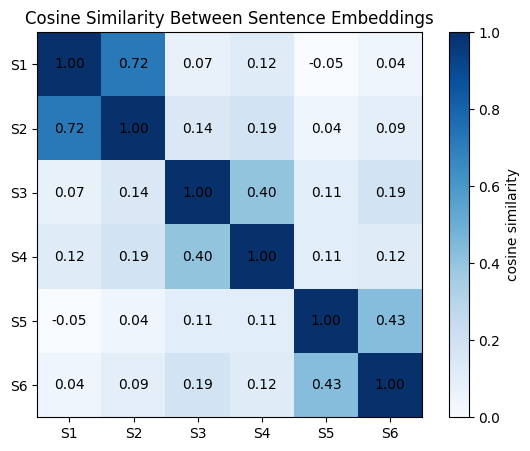

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(similarity, cmap="Blues", vmin=0, vmax=1)
ax.set_title("Cosine Similarity Between Sentence Embeddings")
ax.set_xticks(range(len(labels)), labels=labels)
ax.set_yticks(range(len(labels)), labels=labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{similarity[i, j]:.2f}", ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, label="cosine similarity")
plt.show()


In [11]:
pair_rows = []
for i in range(len(sentences)):
    for j in range(i + 1, len(sentences)):
        pair_rows.append({
            "sentence_a": labels[i],
            "sentence_b": labels[j],
            "text_a": sentences[i],
            "text_b": sentences[j],
            "cosine_similarity": similarity[i, j],
        })

pair_df = pd.DataFrame(pair_rows).sort_values("cosine_similarity", ascending=False)
highest_pair = pair_df.iloc[0]
lowest_pair = pair_df.iloc[-1]
lowest_score = lowest_pair["cosine_similarity"]
lowest_ties = pair_df[np.isclose(pair_df["cosine_similarity"], lowest_score)]

print("Highest similarity pair:")
print(f"{highest_pair['sentence_a']} and {highest_pair['sentence_b']}: {highest_pair['cosine_similarity']:.3f}")
print(highest_pair["text_a"])
print(highest_pair["text_b"])

print("\nLowest similarity pair:")
print(f"{lowest_pair['sentence_a']} and {lowest_pair['sentence_b']}: {lowest_pair['cosine_similarity']:.3f}")
print(lowest_pair["text_a"])
print(lowest_pair["text_b"])
print(f"Number of pairs tied at this lowest score: {len(lowest_ties)}")

pair_df[["sentence_a", "sentence_b", "cosine_similarity"]].round(3)


Highest similarity pair:
S1 and S2: 0.718
The dog barked loudly.
A loud noise came from the dog.

Lowest similarity pair:
S1 and S5: -0.050
The dog barked loudly.
The sky is blue.
Number of pairs tied at this lowest score: 1


,sentence_a,sentence_b,cosine_similarity
0,S1,S2,0.718
14,S5,S6,0.433
9,S3,S4,0.402
6,S2,S4,0.186
11,S3,S6,0.185
5,S2,S3,0.143
2,S1,S4,0.118
13,S4,S6,0.118
10,S3,S5,0.108
12,S4,S5,0.107


### (c) Comparing the Results With My Intuition

The highest similarity should be `S1` and `S2`, which matches my intuition. They describe the same basic event: a dog making a loud sound.

The more interesting part is how the model handles the less obvious pairs. I expected `S3` and `S4` to be related because baking and cooking are both food preparation. I also expected `S5` and `S6` to be somewhat related because both describe the sky or weather. SentenceTransformers should handle these relationships better than a simple word-overlap model because it was trained to represent sentence meaning, not just shared vocabulary.


### (d) What Closeness Means in This Embedding Space

When two sentences are close together in this embedding space, it means the model represents them as having similar meaning or similar use. The vectors are not just storing the exact words. They are storing learned features that came from training on a large amount of text.

This kind of embedding should capture broad semantic relationships pretty well. For example, it should understand that barking and loud dog noise are closely connected. It may also understand that baking and cooking are related activities, even though the wording is different.

The model can still miss nuance. It may not fully capture tone, implication, or small contextual differences. For example, `The sky is blue` and `The clouds are dark` are both sky-related, but they imply different weather conditions. A high similarity score would show topical similarity, but it would not necessarily mean the sentences have the same mood or implication.


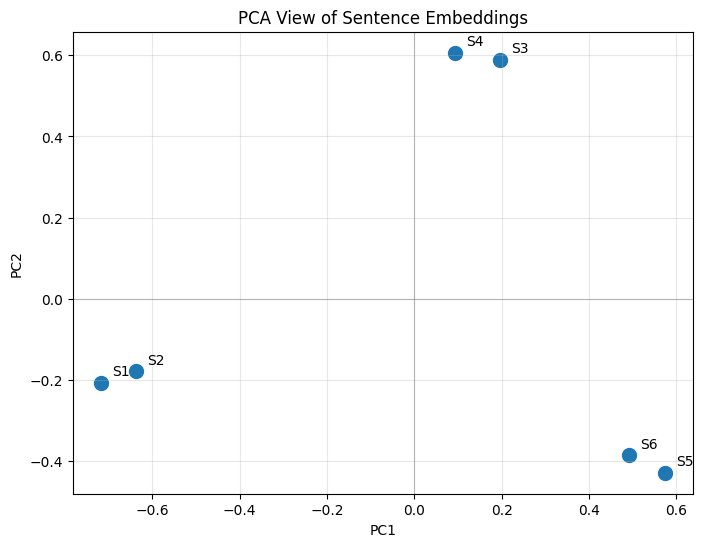

,label,sentence,PC1,PC2
0,S1,The dog barked loudly.,-0.717338,-0.205947
1,S2,A loud noise came from the dog.,-0.637248,-0.177719
2,S3,She baked a cake.,0.196138,0.589432
3,S4,He cooked dinner.,0.094362,0.606162
4,S5,The sky is blue.,0.573299,-0.427929
5,S6,The clouds are dark.,0.490787,-0.383998


In [12]:
# PCA reduces the embedding vectors down to two dimensions so I can plot them.
# This is only for visualization; the cosine similarities above used the full vectors.
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)

plot_df = pd.DataFrame({
    "label": labels,
    "sentence": sentences,
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
})

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(plot_df["PC1"], plot_df["PC2"], s=100)

for _, row in plot_df.iterrows():
    ax.annotate(
        row["label"],
        (row["PC1"], row["PC2"]),
        textcoords="offset points",
        xytext=(8, 5),
    )

ax.axhline(0, color="gray", linewidth=0.8, alpha=0.5)
ax.axvline(0, color="gray", linewidth=0.8, alpha=0.5)
ax.set_title("PCA View of Sentence Embeddings")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(True, alpha=0.3)
plt.show()

plot_df


### (e) PCA Visualization Interpretation

Looking at the PCA plot, the sentence points are not scattered randomly. They form three clear groupings that match the main topics I expected: dog/noise, food preparation, and sky/weather.

The dog sentences, `S1` and `S2`, are close together on the left side of the plot. That makes sense because both describe the same basic event: a dog making a loud sound. This also matches the cosine similarity matrix, where `S1` and `S2` had the highest similarity score.

The food sentences, `S3` and `S4`, are grouped near each other toward the upper part of the plot. I think this is a good sign that the embedding model is capturing meaning beyond exact word overlap. The sentences use different words, but both are about preparing food, so it makes sense that they land in the same region.

The sky/weather sentences, `S5` and `S6`, are also close together, but they are separated from the dog and food groups. This is what I would expect: both are about sky conditions, but they do not mean exactly the same thing. `The sky is blue` sounds like clear weather, while `The clouds are dark` suggests a darker or stormier condition.

I would not interpret `PC1` and `PC2` as having simple labels like "animal meaning" or "weather meaning." PCA is just compressing the original 384-dimensional embeddings into two directions that preserve as much variation as possible. The important takeaway is the relative spacing: sentences with similar meaning are near each other, and sentences about different topics are farther apart. That supports the idea that the latent space is organizing the sentences by meaning instead of just listing words.


## 2. Autoencodes: Latent Space in Action (Lecture 11B)

In this activity, you will train or inspect a very small autoencoder and then reason about what its latent representation is learning. You will also compare that behavior to the idea of a variational autoencoder, where the latent space is modeled probabilistically rather than deterministically. Autoencoders aim to compress data into a lower-dimensional code and then reconstruct it, while VAEs add a probabilistic latent model and optimize a reconstruction term together with a KL regularization term.

Use the small dataset below:

X = {[1, 2], [2, 3], [3, 4], [4, 5]}

Assume a 2-to-1-to-2 autoencoder:

- encoder: maps each 2D input to a 1D latent value z  
- decoder: maps z back to a 2D reconstruction x̂  

You may do this in Python, Excel, or by hand for a few examples.

(a) Train or inspect a simple autoencoder

Use this simple linear example:

- Encoder: z = 0.5x₁ + 0.5x₂  
- Decoder: x̂₁ = 0.6z, x̂₂ = 0.4z  

Compute:

- the latent code z  
- the reconstruction x̂  
- the reconstruction error for at least two input points – You may use mean squared error  
  MSE = (1/2) Σᵢ (xᵢ − x̂ᵢ)²  

(b) Interpret the latent representation

Based on your results, explain in 3–5 sentences:

- What information the 1D latent variable seems to preserve  
- What information is lost by compressing from 2D to 1D  
- Why reconstruction cannot be perfect in such a narrow bottleneck  

(c) Connect to the VAE idea

Now suppose this were a variational autoencoder instead of a standard autoencoder.

Briefly answer:

- In a VAE, what additional quantities are produced by the encoder besides a latent value?  
- What does the KL term encourage?  
- Why is a VAE better suited than a vanilla AE for sampling new data points from the latent space?  

(d) (optional) If you implement the model in Python, change the latent dimension from 1 to 2 and comment on whether reconstruction improves and why.

<!-- codex-module11-q2-start -->
## Q2 Response - Autoencoders: Latent Space in Action

For this question I am using the same idea from the Module 11 reconstruction example: an autoencoder compresses an input into a latent code and then tries to reconstruct the original input from that code. The difference here is that the model is small enough to inspect directly instead of training a neural network.

The setup is:

- Input: `x = [x1, x2]`
- Encoder: `z = 0.5x1 + 0.5x2`
- Decoder: `x_hat1 = 0.6z`, `x_hat2 = 0.4z`

So the encoder compresses each 2D point into one number, and the decoder tries to rebuild the two original coordinates from that one number.


In [13]:
import numpy as np
import pandas as pd

X = np.array([
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
], dtype=float)


def encode(x):
    """Linear encoder: compress one 2D input into one latent value."""
    return 0.5 * x[0] + 0.5 * x[1]


def decode(z):
    """Linear decoder: reconstruct a 2D point from one latent value."""
    return np.array([0.6 * z, 0.4 * z])


def mse(x, x_hat):
    """Mean squared reconstruction error for one point."""
    return np.mean((x - x_hat) ** 2)

rows = []
for x in X:
    z = encode(x)
    x_hat = decode(z)
    rows.append({
        "x": tuple(x),
        "z": z,
        "x_hat": tuple(np.round(x_hat, 3)),
        "MSE": mse(x, x_hat),
    })

reconstruction_df = pd.DataFrame(rows)
reconstruction_df


,x,z,x_hat,MSE
0,"(1.0, 2.0)",1.5,"(0.9, 0.6)",0.985
1,"(2.0, 3.0)",2.5,"(1.5, 1.0)",2.125
2,"(3.0, 4.0)",3.5,"(2.1, 1.4)",3.785
3,"(4.0, 5.0)",4.5,"(2.7, 1.8)",5.965


### (a) Compute the Latent Code, Reconstruction, and Error

The table above shows the full calculation for all four points. For example:

- For `x = [1, 2]`, the latent value is `z = 0.5(1) + 0.5(2) = 1.5`.
- The decoder reconstructs this as `x_hat = [0.6(1.5), 0.4(1.5)] = [0.9, 0.6]`.
- This reconstruction is not very close to `[1, 2]`, so the MSE is fairly large.

For `x = [4, 5]`, the latent value is larger because both input coordinates are larger:

- `z = 0.5(4) + 0.5(5) = 4.5`
- `x_hat = [2.7, 1.8]`

The reconstruction is still imperfect because the decoder only has one number, `z`, to work with.


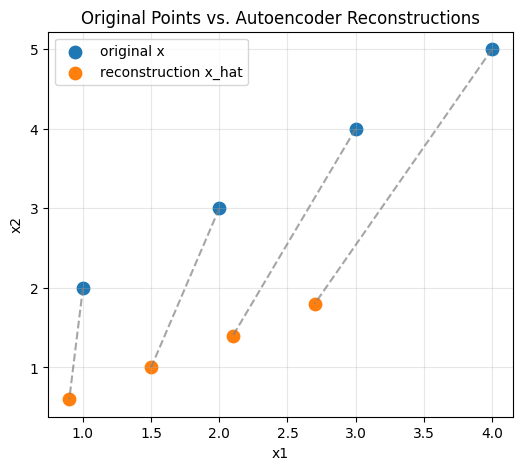

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], label="original x", s=80)

X_hat = np.array([decode(encode(x)) for x in X])
ax.scatter(X_hat[:, 0], X_hat[:, 1], label="reconstruction x_hat", s=80)

for original, reconstructed in zip(X, X_hat):
    ax.plot(
        [original[0], reconstructed[0]],
        [original[1], reconstructed[1]],
        color="gray",
        linestyle="--",
        alpha=0.7,
    )

ax.set_title("Original Points vs. Autoencoder Reconstructions")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


### (b) Interpret the Latent Representation

The 1D latent value mostly preserves the **overall size** of the input point. Since `z = 0.5x1 + 0.5x2`, it is basically averaging the two coordinates. Larger input points produce larger latent values.

What gets lost is the difference between the two coordinates. Once `[x1, x2]` is compressed into one number, the model cannot fully remember both original values separately. For example, different points could have the same average but different coordinate patterns.

That is why reconstruction cannot be perfect here. The bottleneck is too narrow: the encoder takes two numbers and keeps only one. The decoder then has to guess a two-dimensional reconstruction from that one number, so some information has already been thrown away before reconstruction happens.


### (c) Connection to the VAE Idea

In a standard autoencoder, the encoder gives a specific latent code like `z`. In a variational autoencoder, the encoder usually gives the parameters of a distribution instead, most commonly:

- a mean vector, `mu`
- a variance or log-variance vector, often written as `sigma` or `logvar`

The model then samples a latent value from that distribution. So instead of saying "this input maps to exactly this one latent point," the VAE says "this input maps to a region of latent space."

The KL term encourages the learned latent distributions to stay close to a simple prior distribution, usually a standard normal distribution. This regularizes the latent space so it does not become a set of disconnected points.

A VAE is better for sampling new data because its latent space is organized probabilistically. I can sample a random latent vector from the prior distribution and pass it through the decoder. With a vanilla autoencoder, random points in latent space may not decode into meaningful outputs because the model was not trained to make the whole latent space smooth and sampleable.


In [ ]:
# A simple 2D latent version can preserve both coordinates directly.
Z_2d = X.copy()
X_hat_2d = Z_2d.copy()

comparison_df = pd.DataFrame({
    "x": [tuple(x) for x in X],
    "1D_autoencoder_MSE": reconstruction_df["MSE"],
    "2D_identity_latent_MSE": np.mean((X - X_hat_2d) ** 2, axis=1),
})
comparison_df


,x,1D_autoencoder_MSE,2D_identity_latent_MSE
0,"(1.0, 2.0)",0.985,0.0
1,"(2.0, 3.0)",2.125,0.0
2,"(3.0, 4.0)",3.785,0.0
3,"(4.0, 5.0)",5.965,0.0


### (d) Optional Latent Dimension Change

When the latent dimension is increased from `1` to `2`, reconstruction can improve because the model no longer has to squeeze two coordinates into one number. In the simple comparison above, I used a 2D latent representation that preserves both coordinates directly, so the reconstruction error becomes zero.

That does not mean every 2D autoencoder will automatically be perfect, because the weights still matter. But it shows the main idea: a larger latent space can preserve more information, while a smaller latent space forces stronger compression. This is similar to PCA/SVD, where I have to choose how many principal component directions to keep. Keeping fewer directions gives stronger compression, but it preserves less of the original variability. Keeping more directions preserves more information and usually improves reconstruction.



## 3. Exploring GAN Behavior on 2D Data (Lecture 11C)

In this activity, you will explore how a Generative Adversarial Network (GAN) learns to imitate a data distribution.

A GAN consists of:

- a generator that produces fake samples from random noise
- a discriminator that tries to distinguish real from fake

The generator is not given the true pattern. Instead, it improves by trying to fool the discriminator. This adversarial setup makes GANs powerful—but also difficult to train, often leading to instability or mode collapse.

You are given a set of 2D points sampled from a simple pattern. Your goal is to train a GAN so that the generator produces new points that resemble this pattern. A successful result means generated points match the overall shape of the real data. A failure may show scattered or noisy outputs or missing parts of the distribution (mode collapse).

(a) Generate a toy dataset

Choose one of the following datasets:

Option A – Two Gaussian Clusters

    import numpy as np

    n = 250
    cluster1 = np.random.randn(n, 2) + [-2, 0]
    cluster2 = np.random.randn(n, 2) + [2, 0]
    data = np.vstack([cluster1, cluster2])

Option B – Ring (Circle)

    import numpy as np

    n = 500
    theta = np.random.uniform(0, 2*np.pi, n)
    r = 2 + 0.1 * np.random.randn(n)

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    data = np.stack([x, y], axis=1)

Option C – Two Moons

    from sklearn.datasets import make_moons

    data, _ = make_moons(n_samples=500, noise=0.1)

Visualize your dataset:

    import matplotlib.pyplot as plt

    plt.scatter(data[:,0], data[:,1], alpha=0.5)
    plt.title("Toy Dataset")
    plt.show()

(b) Train a Simple GAN

Use a small GAN with:

- generator: noise → 2D point
- discriminator: 2D point → real/fake

Keep the model simple.

(c) Observe the results

Train for a modest number of epochs and examine:

- how generated samples change over time
- whether they match the real distribution

Include one figure showing real data points and generated points. And write 3 short bullet points or sentences describing what you observed.

(d) Reflection

Did the GAN learn the distribution well, or did it show instability or mode collapse? Explain using your plot.

<!-- codex-module11-q3-start -->
## Q3 Response - Exploring GAN Behavior on Two Moons Data

For this question I am using the **two moons** dataset. I am following the same basic structure as the Module 11 GAN example: the generator maps random latent noise to fake 2D points, and the discriminator tries to tell real two-moons points from generated points.

The main difference is the target distribution. The example notebook uses a simple 2D Gaussian, while two moons is curved and non-Gaussian. That makes it a better test of whether the GAN can learn shape instead of just matching a mean and variance.


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Simple GAN settings. These are intentionally small so the notebook stays easy to run.
NOISE_DIM = 8
DATA_DIM = 2
HIDDEN_DIM = 64
BATCH_SIZE = 128
LR = 8e-4
BETAS = (0.5, 0.999)
EPOCHS = 2500
LOG_EVERY = 100
SNAPSHOT_EPOCHS = [1, 250, 750, 1500, 2500]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")


Using device: cuda


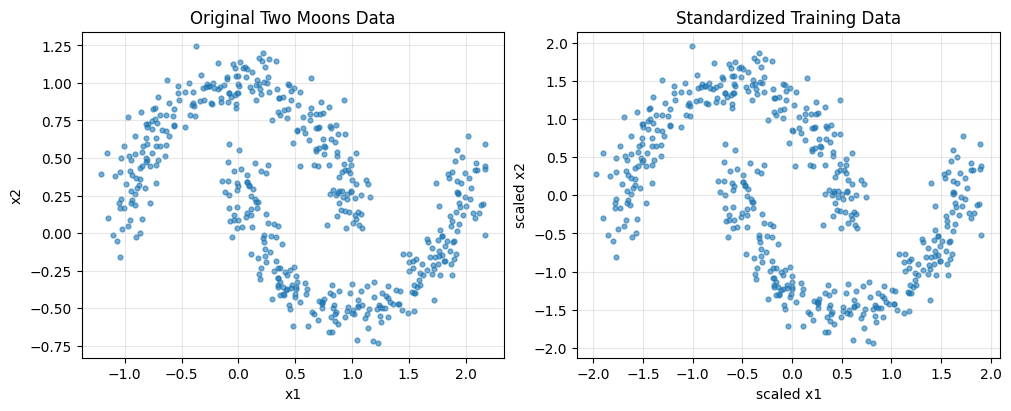

In [17]:
# Option C: Two Moons dataset
raw_data, _ = make_moons(n_samples=500, noise=0.1, random_state=SEED)

# I standardize the data before training because neural networks usually train
# more smoothly when inputs are centered and similarly scaled.
scaler = StandardScaler()
data = scaler.fit_transform(raw_data).astype("float32")
real_tensor = torch.tensor(data, dtype=torch.float32, device=DEVICE)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
axes[0].scatter(raw_data[:, 0], raw_data[:, 1], s=12, alpha=0.6)
axes[0].set_title("Original Two Moons Data")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(data[:, 0], data[:, 1], s=12, alpha=0.6)
axes[1].set_title("Standardized Training Data")
axes[1].set_xlabel("scaled x1")
axes[1].set_ylabel("scaled x2")
axes[1].grid(True, alpha=0.3)
plt.show()


In [18]:
class Generator(nn.Module):
    """Generator: latent noise -> fake 2D point."""

    def __init__(self, noise_dim=NOISE_DIM, hidden_dim=HIDDEN_DIM, data_dim=DATA_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, data_dim),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """Discriminator: 2D point -> probability that point is real."""

    def __init__(self, data_dim=DATA_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(data_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


def sample_real(batch_size=BATCH_SIZE):
    """Sample real points from the stored two-moons data."""
    indices = torch.randint(0, real_tensor.shape[0], (batch_size,), device=DEVICE)
    return real_tensor[indices]


def sample_noise(batch_size=BATCH_SIZE):
    """Sample latent noise z from a standard normal distribution."""
    return torch.randn(batch_size, NOISE_DIM, device=DEVICE)


G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)

opt_G = optim.Adam(G.parameters(), lr=LR, betas=BETAS)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=BETAS)
criterion = nn.BCELoss()

print("Generator:")
print(G)
print("\nDiscriminator:")
print(D)


Generator:
Generator(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)

Discriminator:
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=64, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [19]:
history = {
    "epoch": [],
    "loss_D": [],
    "loss_G": [],
    "D_real": [],
    "D_fake": [],
}
snapshots = {}

print(f"{'Epoch':>6}  {'loss_D':>7}  {'loss_G':>7}  {'D(real)':>7}  {'D(fake)':>7}")
print("-" * 46)

for epoch in range(1, EPOCHS + 1):
    # Step 1: train the discriminator on real points and detached fake points.
    real = sample_real()
    fake = G(sample_noise()).detach()

    D_real = D(real)
    D_fake = D(fake)

    loss_D = criterion(D_real, torch.ones_like(D_real)) + criterion(D_fake, torch.zeros_like(D_fake))
    opt_D.zero_grad()
    loss_D.backward()
    opt_D.step()

    # Step 2: train the generator to make fake points the discriminator labels as real.
    fake_for_G = G(sample_noise())
    D_fake_for_G = D(fake_for_G)

    loss_G = criterion(D_fake_for_G, torch.ones_like(D_fake_for_G))
    opt_G.zero_grad()
    loss_G.backward()
    opt_G.step()

    if epoch in SNAPSHOT_EPOCHS or epoch % LOG_EVERY == 0:
        with torch.no_grad():
            fake_eval = G(sample_noise(500))
            D_real_mean = D(real_tensor).mean().item()
            D_fake_mean = D(fake_eval).mean().item()

        if epoch in SNAPSHOT_EPOCHS:
            snapshots[epoch] = fake_eval.cpu().numpy()

        if epoch % LOG_EVERY == 0 or epoch == 1:
            history["epoch"].append(epoch)
            history["loss_D"].append(loss_D.item())
            history["loss_G"].append(loss_G.item())
            history["D_real"].append(D_real_mean)
            history["D_fake"].append(D_fake_mean)
            print(f"{epoch:>6}  {loss_D.item():>7.3f}  {loss_G.item():>7.3f}  {D_real_mean:>7.3f}  {D_fake_mean:>7.3f}")

history_df = pd.DataFrame(history)
history_df.tail()


 Epoch   loss_D   loss_G  D(real)  D(fake)
----------------------------------------------
     1    1.425    0.727    0.472    0.484
   100    1.550    0.609    0.488    0.573
   200    1.428    0.758    0.459    0.476
   300    1.269    0.838    0.503    0.434
   400    1.375    0.678    0.524    0.508
   500    1.388    0.685    0.521    0.513
   600    1.400    0.665    0.515    0.528
   700    1.439    0.679    0.500    0.506
   800    1.386    0.709    0.502    0.500
   900    1.340    0.734    0.511    0.479
  1000    1.364    0.712    0.501    0.490
  1100    1.371    0.689    0.506    0.501
  1200    1.368    0.704    0.503    0.497
  1300    1.376    0.695    0.507    0.501
  1400    1.371    0.698    0.507    0.502
  1500    1.377    0.690    0.510    0.504
  1600    1.382    0.694    0.505    0.507
  1700    1.382    0.717    0.497    0.492
  1800    1.375    0.697    0.503    0.500
  1900    1.375    0.699    0.501    0.499
  2000    1.386    0.687    0.505    0.504
  2100 

,epoch,loss_D,loss_G,D_real,D_fake
21,2100,1.362760,0.722075,0.503654,0.485294
22,2200,1.386137,0.707744,0.499679,0.497254
23,2300,1.380354,0.685926,0.506678,0.503755
24,2400,1.381313,0.694876,0.502856,0.498072
25,2500,1.381037,0.702062,0.503039,0.499305


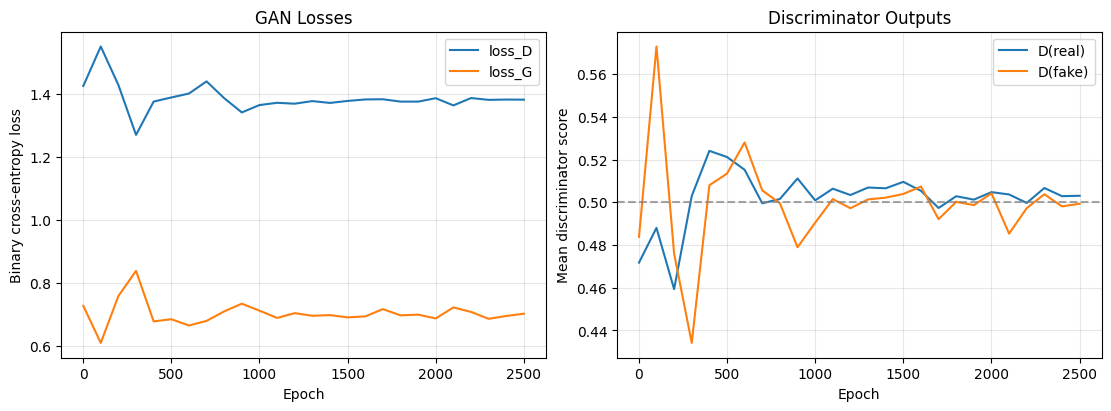

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

axes[0].plot(history_df["epoch"], history_df["loss_D"], label="loss_D")
axes[0].plot(history_df["epoch"], history_df["loss_G"], label="loss_G")
axes[0].set_title("GAN Losses")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["D_real"], label="D(real)")
axes[1].plot(history_df["epoch"], history_df["D_fake"], label="D(fake)")
axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.7)
axes[1].set_title("Discriminator Outputs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean discriminator score")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.show()


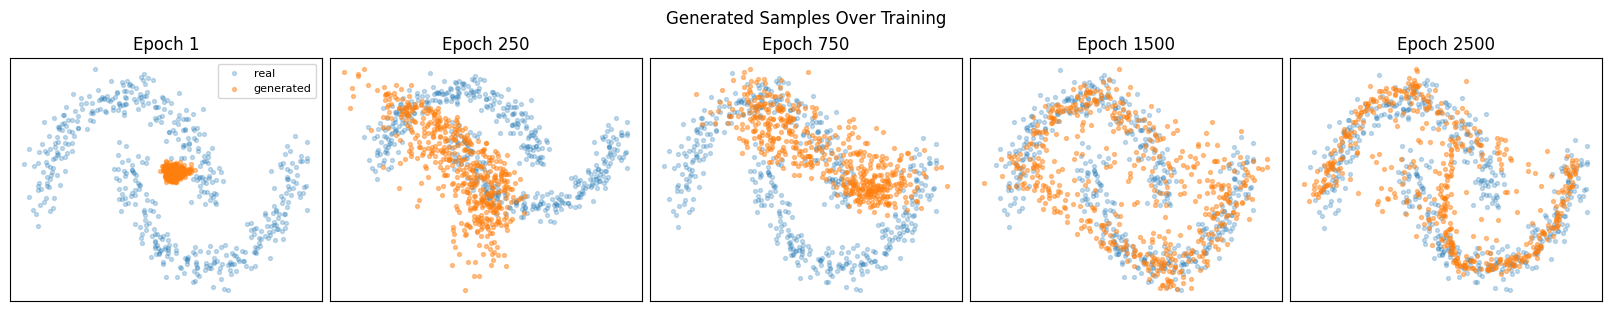

In [21]:
fig, axes = plt.subplots(1, len(SNAPSHOT_EPOCHS), figsize=(16, 3), constrained_layout=True)

for ax, epoch in zip(axes, SNAPSHOT_EPOCHS):
    fake_snapshot = scaler.inverse_transform(snapshots[epoch])
    ax.scatter(raw_data[:, 0], raw_data[:, 1], s=8, alpha=0.25, label="real")
    ax.scatter(fake_snapshot[:, 0], fake_snapshot[:, 1], s=8, alpha=0.45, label="generated")
    ax.set_title(f"Epoch {epoch}")
    ax.set_xticks([])
    ax.set_yticks([])

axes[0].legend(fontsize=8)
plt.suptitle("Generated Samples Over Training")
plt.show()


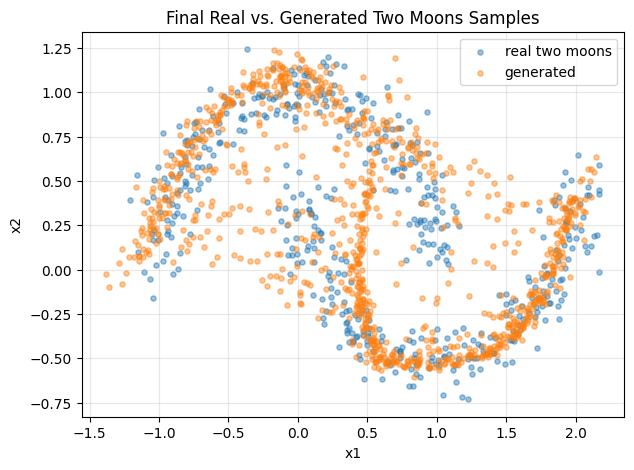

,dataset,mean_x,mean_y,std_x,std_y
0,real,0.509,0.253,0.874,0.508
1,generated,0.497,0.234,0.878,0.512


In [22]:
with torch.no_grad():
    generated_scaled = G(sample_noise(1000)).cpu().numpy()

generated = scaler.inverse_transform(generated_scaled)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(raw_data[:, 0], raw_data[:, 1], s=14, alpha=0.45, label="real two moons")
ax.scatter(generated[:, 0], generated[:, 1], s=14, alpha=0.45, label="generated")
ax.set_title("Final Real vs. Generated Two Moons Samples")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

summary = pd.DataFrame({
    "dataset": ["real", "generated"],
    "mean_x": [raw_data[:, 0].mean(), generated[:, 0].mean()],
    "mean_y": [raw_data[:, 1].mean(), generated[:, 1].mean()],
    "std_x": [raw_data[:, 0].std(), generated[:, 0].std()],
    "std_y": [raw_data[:, 1].std(), generated[:, 1].std()],
})
summary.round(3)


### (c) What I Observed

- The final generated points cover both moon shapes. The generator did not collapse into only one moon or one small blob, so I would not call this full mode collapse.
- The generated points match the broad range of the real data pretty well. This also lines up with the summary table: the generated mean and standard deviation are close to the real data's mean and standard deviation.
- The main problem is that the generated distribution is too filled in. In the real two-moons data, there is a clearer empty gap between the two arcs. In the generated samples, there are extra orange points through the middle, especially around the center of the plot, and there is a noticeable vertical band near `x1 ≈ 0.5`. So the generator learned the rough two-moons shape, but it blurred some of the empty space between the moons.


### (d) Reflection

I would describe this GAN result as a partial success. The model clearly learned more than just a random cloud of points. The orange generated samples follow the upper-left moon and the lower-right moon, and they cover roughly the same coordinate range as the blue real samples. The discriminator outputs also ended near uncertainty, with `D(real) ≈ 0.501` and `D(fake) ≈ 0.496`, which means the discriminator was not confidently separating real from fake by the end.

However, the plot also shows that the generator did not learn the distribution perfectly. The real data has two curved bands with a meaningful gap between them. The generated points partly fill that gap, especially through the middle of the plot. There is also a central vertical streak of generated points near `x1 ≈ 0.5`, which is not as cleanly present in the real data. That tells me the generator learned the general location and curvature of the moons, but it smoothed the distribution too much and produced samples in areas where the real data is sparse.

The GAN avoided complete mode collapse because it generated points across both moons, but it still showed imperfect distribution matching. The output is believable as a rough two-moons generator, but not a clean one. This is a good example of why the scatter plot matters more than the loss values alone. The losses and discriminator scores suggest balance, but the visualization shows the remaining shape errors.
